# Polar Twist Example with mPCN

This notebook implements a compact polar-twist Bayesian inverse problem and fits it with mPCN.

Workflow:
1. Define the polar-twist forward map and Gaussian likelihood
2. Generate synthetic observed data
3. Build the posterior via `ToyCustomLikelihood2D`
4. Sample with `mpcn_chain`
5. Inspect trace, scatter, and posterior center

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.ampcn import ampcn_chain
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D

print(f"Repo root: {repo_root}")

Repo root: /home/senng/mcmc-internal


In [8]:
def f_polar_twist(x, alpha, weight_x=1.0, weight_y=1.0):
    x1, x2 = x
    r = np.sqrt(x1**2 + x2**2)
    c1 = x1 * np.cos(alpha * weight_x * r) - x2 * np.sin(alpha * weight_y * r)
    c2 = x1 * np.sin(alpha * weight_x * r) + x2 * np.cos(alpha * weight_y * r)
    return np.array([c1, c2])

def log_likelihood_polar_twist(x, y_obs, sigma, alpha, weight_x, weight_y):
    residual = f_polar_twist(x, alpha=alpha, weight_x=weight_x, weight_y=weight_y) - y_obs
    return -0.5 * np.dot(residual, residual) / (sigma**2)

# Synthetic data configuration
alpha = 0.4
weight_x = 0.3
weight_y = 4.0
sigma_noise = 3.0
prior_std = 3.0
prior_mean = np.zeros(2)
prior_cov = prior_std**2 * np.array([[1.0, 0.3], [0.3, 1.0]])
data_seed = 202

rng = np.random.default_rng(data_seed)
x_true = rng.multivariate_normal(prior_mean, prior_cov)
y_obs = f_polar_twist(x_true, alpha=alpha, weight_x=weight_x, weight_y=weight_y) + rng.normal(
    0.0, sigma_noise, size=2
)

def log_likelihood(x):
    return log_likelihood_polar_twist(
        x, y_obs, sigma=sigma_noise, alpha=alpha, weight_x=weight_x, weight_y=weight_y
    )

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print("Observed data y_obs:", y_obs)
print("True latent x:", x_true)

Observed data y_obs: [-9.95629816  0.09950474]
True latent x: [-3.08802523 -5.67590864]


In [13]:
# Fit with mPCN
n_iters = 10000
rho = 0.5
n_props = 20
mcmc_seed = 202

rng_mcmc = np.random.default_rng(mcmc_seed)
x0 = problem.sample_prior(rng_mcmc)
chain_mpcn, accepted_index = mpcn_chain(
    x0,
    problem,
    rng_mcmc,
    n_iters,
    rho=rho,
    n_props=n_props,
    return_indices=True,
)

burn_in = 1000
post = chain_mpcn[burn_in:]
accept_rate = np.mean(accepted_index != 0)
ess = estimate_effective_sample_size(post, max_lag=300)

print(f"mPCN done: n_iters={n_iters}, rho={rho}, n_props={n_props}")
print(f"Acceptance rate: {accept_rate:.3f}")
print("Posterior mean:", post.mean(axis=0))
print("Posterior std:", post.std(axis=0))
print("ESS per component:", np.asarray(ess, dtype=float))

Estimating ESS for each parameter.
mPCN done: n_iters=10000, rho=0.5, n_props=20
Acceptance rate: 0.759
Posterior mean: [-2.73658693 -0.93225796]
Posterior std: [2.10407219 3.83212168]
ESS per component: [4151.00747027 2412.4147732 ]


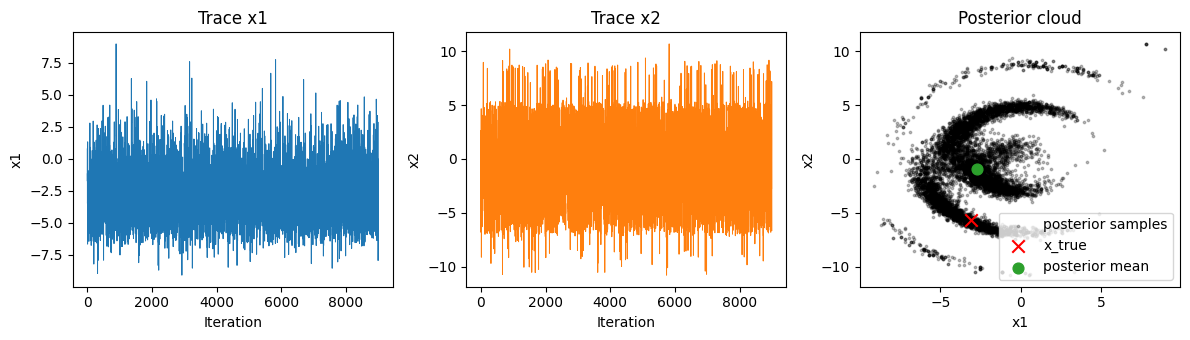

In [14]:
# Quick diagnostics
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(post[:, 0], lw=0.7, color="tab:blue")
axes[0].set_title("Trace x1")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("x1")

axes[1].plot(post[:, 1], lw=0.7, color="tab:orange")
axes[1].set_title("Trace x2")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("x2")

axes[2].scatter(post[:, 0], post[:, 1], s=3, alpha=0.25, color="black", label="posterior samples")
axes[2].scatter([x_true[0]], [x_true[1]], color="red", s=80, marker="x", label="x_true")
axes[2].scatter([post[:, 0].mean()], [post[:, 1].mean()], color="tab:green", s=60, label="posterior mean")
axes[2].set_title("Posterior cloud")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")
axes[2].legend(loc="best")

fig.tight_layout()
plt.show()

Estimating ESS for each parameter.
aMPCN summary
  acceptance rate: 0.739
  final rho: 0.0038
  posterior mean: [-2.73418277 -0.94536637]
  posterior std: [2.10278111 3.82600941]
  ESS per component: [5339.2473271  3687.72523404]

Comparison vs mPCN
  mPCN acceptance:  0.759
  aMPCN acceptance: 0.739
  mPCN ESS: [4151.00747027 2412.4147732 ]
  aMPCN ESS: [5339.2473271  3687.72523404]


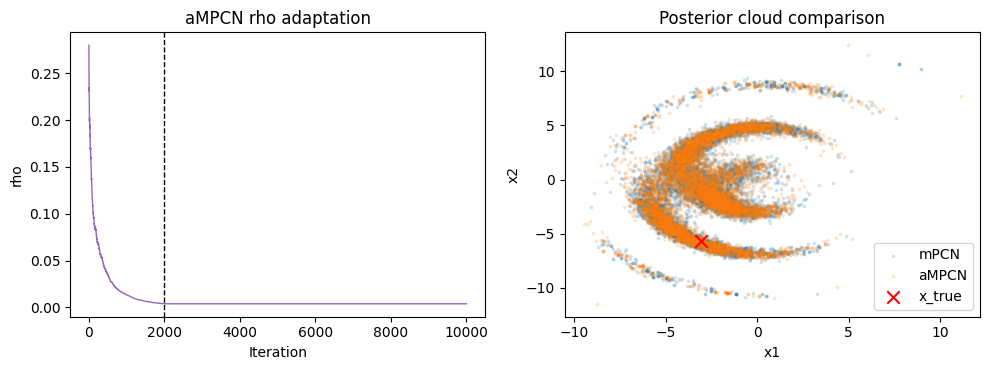

In [17]:
# aMPCN: adaptive rho variant based on mPCN
rng_ampcn = np.random.default_rng(mcmc_seed)
x0_ampcn = x0.copy()

chain_ampcn, idx_ampcn, rho_hist = ampcn_chain(
    x0_ampcn,
    problem,
    rng_ampcn,
    n_iters=n_iters,
    rho_init=0.3,
    n_props=n_props,
    adapt_iters=2000,
    target_accept=0.35,
    step_scale=0.15,
    rho_bounds=(1e-3, 0.999),
    return_indices=True,
)

post_ampcn = chain_ampcn[burn_in:]
accept_rate_ampcn = np.mean(idx_ampcn != 0)
ess_ampcn = np.asarray(estimate_effective_sample_size(post_ampcn, max_lag=300), dtype=float)

print("aMPCN summary")
print(f"  acceptance rate: {accept_rate_ampcn:.3f}")
print(f"  final rho: {rho_hist[-1]:.4f}")
print("  posterior mean:", post_ampcn.mean(axis=0))
print("  posterior std:", post_ampcn.std(axis=0))
print("  ESS per component:", ess_ampcn)

print("\nComparison vs mPCN")
print(f"  mPCN acceptance:  {accept_rate:.3f}")
print(f"  aMPCN acceptance: {accept_rate_ampcn:.3f}")
print("  mPCN ESS:", np.asarray(ess, dtype=float))
print("  aMPCN ESS:", ess_ampcn)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(rho_hist, color="tab:purple", lw=1.0)
axes[0].axvline(2000, color="black", ls="--", lw=1.0)
axes[0].set_title("aMPCN rho adaptation")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("rho")

axes[1].scatter(post[:, 0], post[:, 1], s=3, alpha=0.15, label="mPCN", color="tab:blue")
axes[1].scatter(post_ampcn[:, 0], post_ampcn[:, 1], s=3, alpha=0.15, label="aMPCN", color="tab:orange")
axes[1].scatter([x_true[0]], [x_true[1]], color="red", marker="x", s=80, label="x_true")
axes[1].set_title("Posterior cloud comparison")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].legend(loc="best")

fig.tight_layout()
plt.show()